# M4 — Exploratory Data Analytics: MovieLens 100K

This notebook performs univariate, bivariate, and multivariate exploratory analysis on the cleaned MovieLens 100K dataset (`../data/processed/ml100k_clean.csv`), supplemented with movie genre metadata from the raw files.

**Deliverable requirement:** at least 8 visualisations, each with a written interpretation.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def resolve_paths():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "M4"]
    for m4_dir in candidates:
        root = m4_dir.parent
        data_ok = (root / "data" / "processed" / "ml100k_clean.csv").exists()
        notebook_ok = (m4_dir / "eda_ml100k.ipynb").exists()
        if data_ok and notebook_ok:
            return m4_dir, root
    raise FileNotFoundError(
        "Cannot find project data. Open Jupyter from the M4/ folder, "
        "or from the project root (课程2/) so ../data/processed/ml100k_clean.csv exists."
    )

M4_DIR, ROOT = resolve_paths()
CLEAN_PATH = ROOT / "data" / "processed" / "ml100k_clean.csv"
RAW_DIR = ROOT / "data" / "raw" / "ml-100k"
FIG_DIR = M4_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"M4_DIR: {M4_DIR}")
print(f"ROOT:   {ROOT}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "figure.figsize": (8, 5)})

df = pd.read_csv(CLEAN_PATH, parse_dates=["timestamp", "release_date"])
df["rating_date"] = pd.to_datetime(df["rating_date"])

# Load genre metadata for multivariate analysis
genre_map = (
    pd.read_csv(RAW_DIR / "u.genre", sep="|", header=None, names=["genre", "genre_id"])
    .query("genre != 'unknown'")
)
genre_cols = [f"genre_{i}" for i in range(19)]
item_cols = ["item_id", "movie_title", "release_date_raw", "video_release_date", "imdb_url"] + genre_cols
items = pd.read_csv(RAW_DIR / "u.item", sep="|", header=None, encoding="latin-1", names=item_cols)

genre_long = (
    items.melt(id_vars="item_id", value_vars=genre_cols, var_name="genre_col", value_name="flag")
    .query("flag == 1")
    .assign(genre_id=lambda d: d["genre_col"].str.replace("genre_", "").astype(int))
    .merge(genre_map, on="genre_id", how="left")[["item_id", "genre"]]
)

df["age_group"] = pd.cut(df["age"], bins=[0, 18, 25, 35, 45, 55, 100],
                           labels=["<18", "18-24", "25-34", "35-44", "45-54", "55+"])
df["release_decade"] = (df["release_year"] // 10 * 10).astype("Int64")

df_genre = df.merge(genre_long, on="item_id", how="left")

print(f"Rows: {len(df):,} | Users: {df['user_id'].nunique():,} | Movies: {df['item_id'].nunique():,}")
df.head()

M4_DIR: C:\Users\admin\Desktop\数据科学项目\推荐系统\课程2\M4
ROOT:   C:\Users\admin\Desktop\数据科学项目\推荐系统\课程2
Rows: 100,000 | Users: 943 | Movies: 1,682


,user_id,item_id,rating,timestamp,movie_title,release_date,age,gender,occupation,zip_code,rating_date,release_year,age_group,release_decade
0,196,242,3,1997-12-04 15:55:49,Kolya (1996),1997-01-24,49,M,writer,55105,1997-12-04,1997.0,45-54,1990
1,186,302,3,1998-04-04 19:22:22,L.A. Confidential (1997),1997-01-01,39,F,executive,00000,1998-04-04,1997.0,35-44,1990
2,22,377,1,1997-11-07 07:18:36,Heavyweights (1994),1994-01-01,25,M,writer,40206,1997-11-07,1994.0,18-24,1990
3,244,51,2,1997-11-27 05:02:03,Legends of the Fall (1994),1994-01-01,28,M,technician,80525,1997-11-27,1994.0,25-34,1990
4,166,346,1,1998-02-02 05:33:16,Jackie Brown (1997),1997-01-01,47,M,educator,55113,1998-02-02,1997.0,45-54,1990


---
## 1. Univariate — Rating Distribution

**Takeaway:** Ratings are positively skewed: grades 4 and 5 account for more than half of all interactions, while rating 1 is rare (~6%). This imbalance implies that models optimising RMSE may under-predict extreme low ratings, and that a binary "liked (≥4) vs not" framing could be more stable than treating all five stars equally.

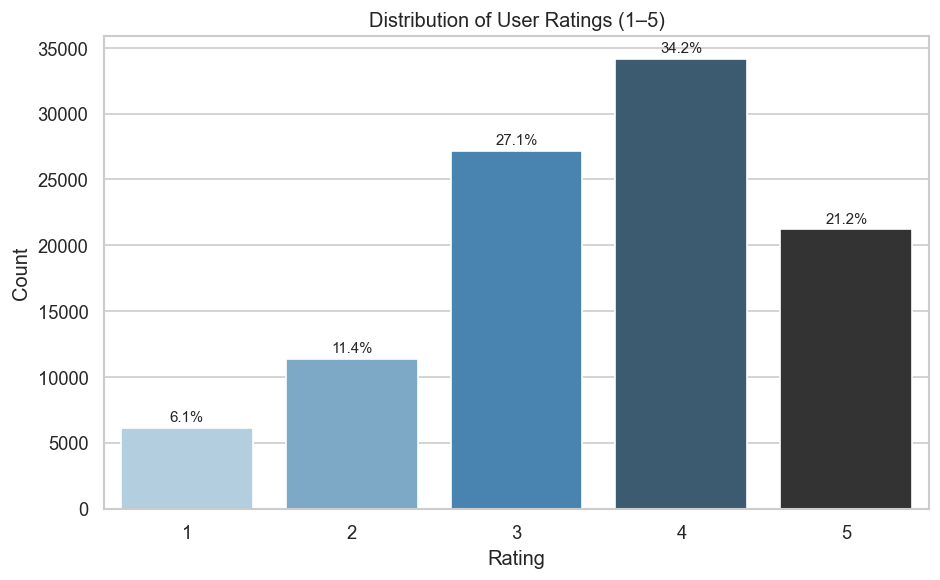

In [14]:
rating_counts = df["rating"].value_counts().sort_index().reset_index()
rating_counts.columns = ["rating", "count"]
fig, ax = plt.subplots()
sns.barplot(data=rating_counts, x="rating", y="count", hue="rating",
            palette="Blues_d", legend=False, ax=ax)
ax.set_title("Distribution of User Ratings (1–5)")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
for i, row in rating_counts.iterrows():
    ax.text(i, row["count"] + 500, f"{row['count']/len(df):.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_rating_distribution.png")
plt.show()

---
## 2. Univariate — User Age Distribution

**Takeaway:** The user base clusters around young adults: the median age is 25 and the mode is in the 18–24 band. Older users (45+) are a long tail. Demographic-aware models should not assume uniform age representation; cold-start users in older brackets will have sparse training signal.

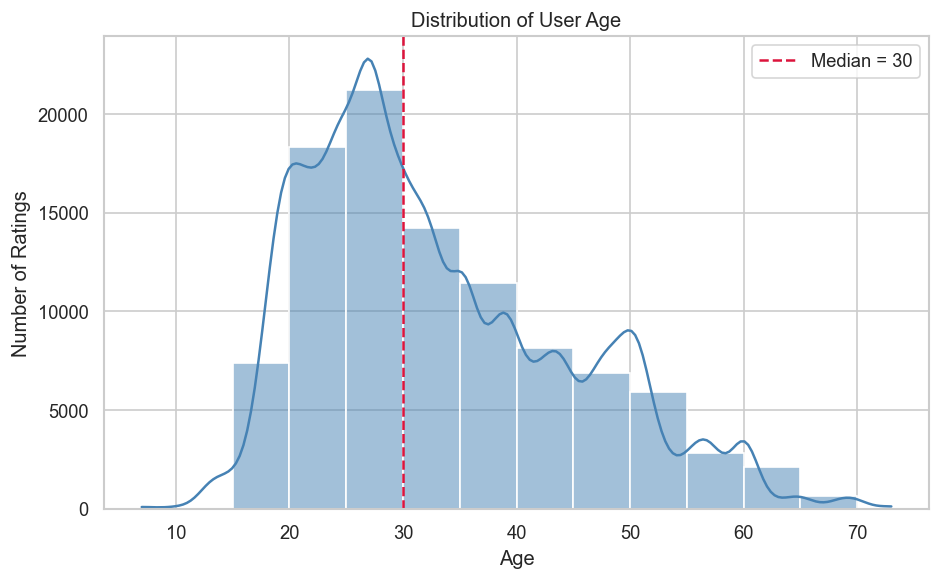

In [15]:
fig, ax = plt.subplots()
sns.histplot(df["age"], bins=range(15, 75, 5), kde=True, color="steelblue", ax=ax)
ax.axvline(df["age"].median(), color="crimson", linestyle="--", label=f"Median = {df['age'].median():.0f}")
ax.set_title("Distribution of User Age")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Ratings")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_age_distribution.png")
plt.show()

---
## 3. Univariate — Movie Release Decade

**Takeaway:** Most rated movies were released in the 1990s, reflecting both catalogue availability and user interest at collection time (1997–1998). Historical films before 1970 appear infrequently. Item-based models must handle a heavy temporal bias toward recent releases rather than a uniform movie catalogue.

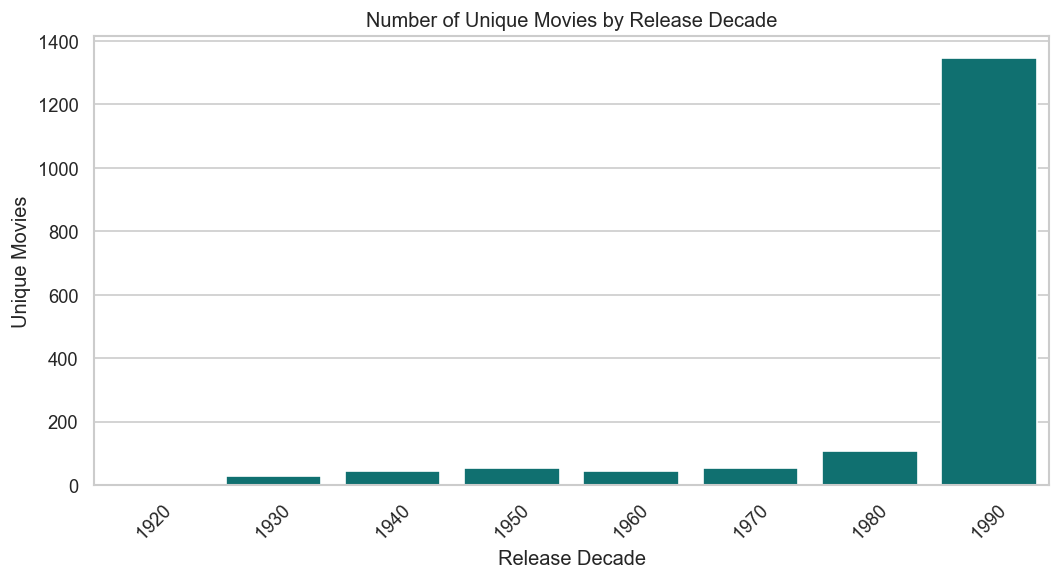

In [16]:
decade_counts = df.drop_duplicates("item_id").dropna(subset=["release_decade"])
decade_counts = decade_counts["release_decade"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=decade_counts.index.astype(str), y=decade_counts.values, color="teal", ax=ax)
ax.set_title("Number of Unique Movies by Release Decade")
ax.set_xlabel("Release Decade")
ax.set_ylabel("Unique Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_release_decade.png")
plt.show()

---
## 4. Univariate — User Activity (Ratings per User)

**Takeaway:** Every user rated at least 20 movies (dataset constraint), but activity is right-skewed: a minority of power users contribute disproportionately many ratings. Collaborative filtering will rely on a relatively small set of highly active users to anchor similarity estimates.

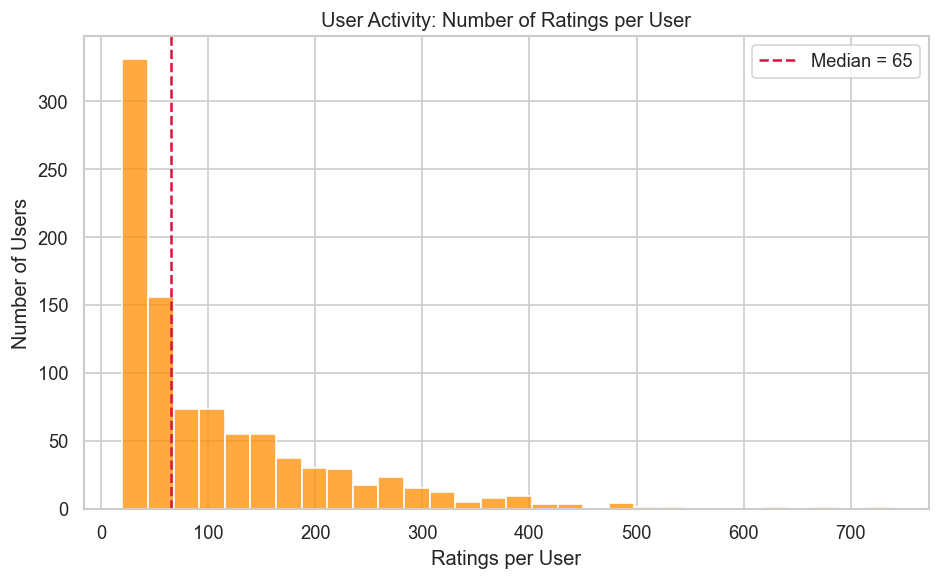

Min ratings/user: 20 | Max: 737 | Median: 65


In [17]:
user_activity = df.groupby("user_id").size()
fig, ax = plt.subplots()
sns.histplot(user_activity, bins=30, color="darkorange", ax=ax)
ax.set_title("User Activity: Number of Ratings per User")
ax.set_xlabel("Ratings per User")
ax.set_ylabel("Number of Users")
ax.axvline(user_activity.median(), color="crimson", linestyle="--",
           label=f"Median = {user_activity.median():.0f}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_user_activity.png")
plt.show()
print(f"Min ratings/user: {user_activity.min()} | Max: {user_activity.max()} | Median: {user_activity.median():.0f}")

---
## 5. Bivariate — Rating vs Gender

**Takeaway:** Male users contribute ~74% of ratings and show a slightly higher median than female users, but the distributions largely overlap. Gender alone is a weak separator of rating behaviour; it may still help as a side feature in matrix factorisation but is unlikely to be a primary predictive signal.

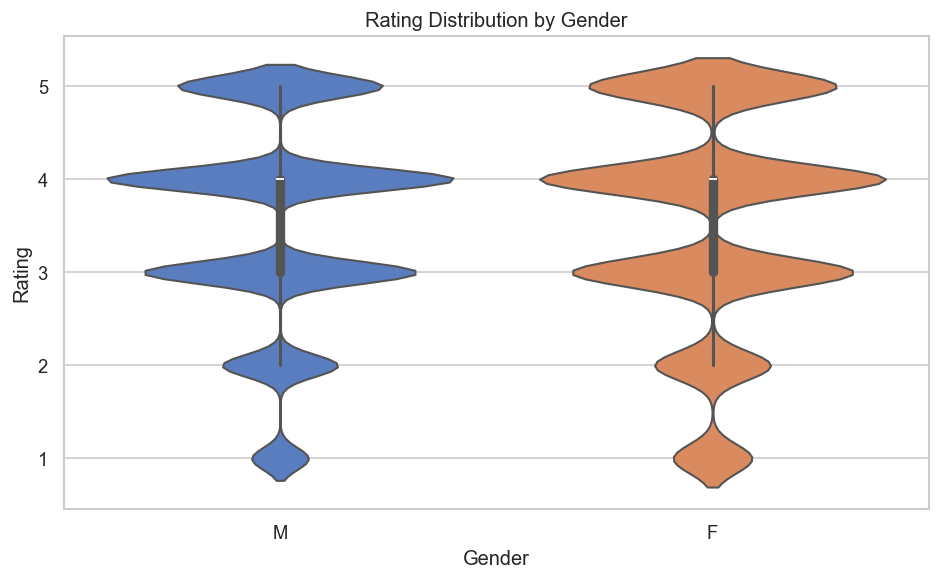

            mean  median  count
gender                         
F       3.531507     4.0  25740
M       3.529289     4.0  74260


In [18]:
fig, ax = plt.subplots()
sns.violinplot(data=df, x="gender", y="rating", hue="gender",
               order=["M", "F"], palette="muted", legend=False, inner="box", ax=ax)
ax.set_title("Rating Distribution by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_rating_by_gender.png")
plt.show()
print(df.groupby("gender")["rating"].agg(["mean", "median", "count"]))

---
## 6. Bivariate — Average Rating by Age Group

**Takeaway:** Users aged 18–24 give the lowest mean ratings (3.47), while ratings rise steadily with age, reaching 3.65 for users 55+. The youngest cohort (<18) is a small group with slightly above-average scores. Contrary to a "harsh young critic" stereotype, it is young adults — not seniors — who rate most strictly. Age should be included as a binned feature with a monotonic upward trend.

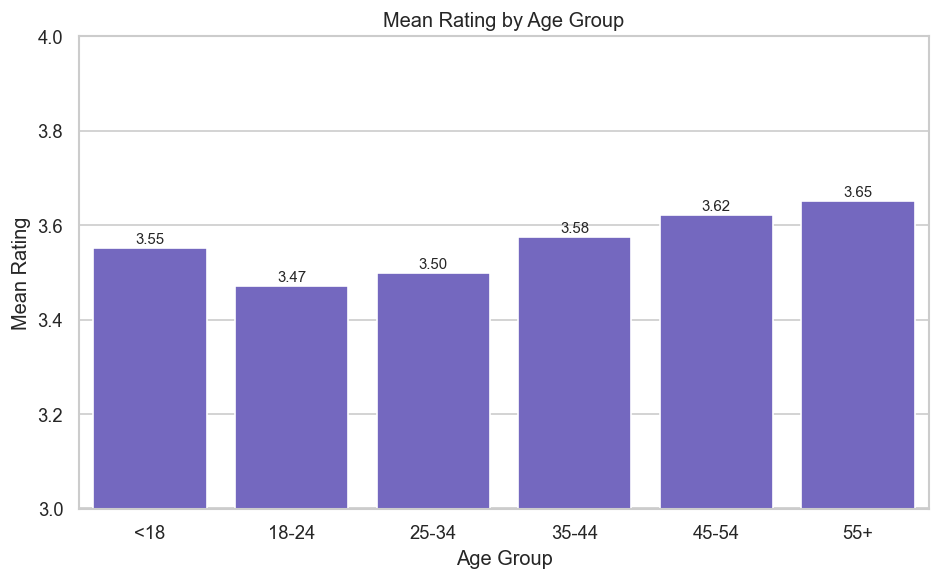

In [19]:
age_rating = df.groupby("age_group", observed=True)["rating"].mean().reset_index()
fig, ax = plt.subplots()
sns.barplot(data=age_rating, x="age_group", y="rating", color="slateblue", ax=ax)
ax.set_title("Mean Rating by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Mean Rating")
ax.set_ylim(3.0, 4.0)
for i, row in age_rating.iterrows():
    ax.text(i, row["rating"] + 0.01, f"{row['rating']:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_rating_by_age_group.png")
plt.show()

---
## 7. Bivariate — Mean Rating by Occupation (Top 10)

**Takeaway:** Occupations differ modestly in mean rating (range roughly 3.5–3.8). Retired users and homemakers trend higher; students — the largest group — sit near the global mean. Occupation captures lifestyle-related taste differences but effect sizes are small relative to within-user variance.

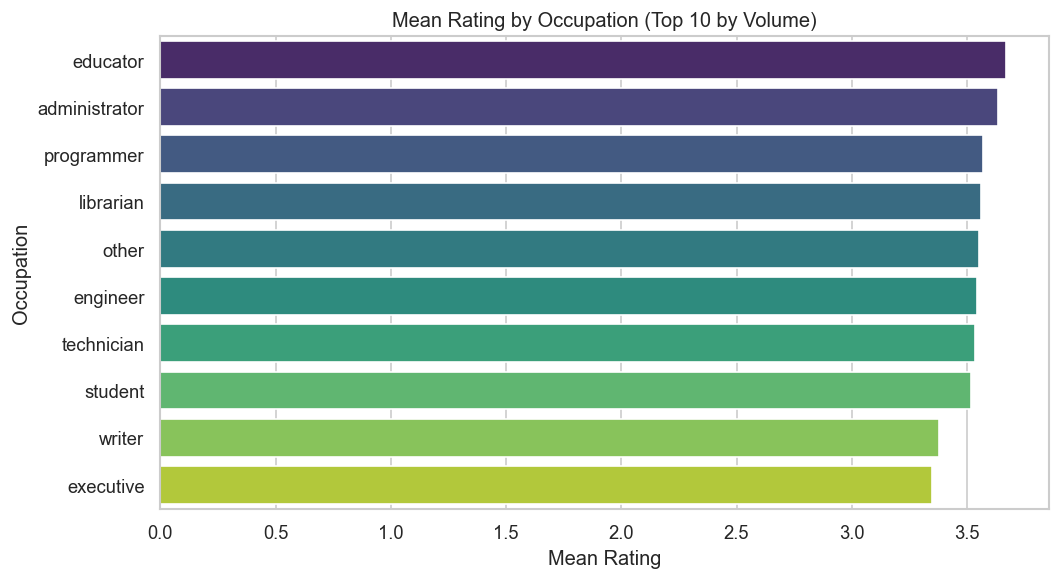

In [20]:
occ_stats = (
    df.groupby("occupation")["rating"]
    .agg(mean_rating="mean", count="count")
    .sort_values("count", ascending=False)
    .head(10)
    .sort_values("mean_rating", ascending=False)
    .reset_index()
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=occ_stats, x="mean_rating", y="occupation", hue="occupation",
            palette="viridis", legend=False, ax=ax)
ax.set_title("Mean Rating by Occupation (Top 10 by Volume)")
ax.set_xlabel("Mean Rating")
ax.set_ylabel("Occupation")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_rating_by_occupation.png")
plt.show()

---
## 8. Bivariate — Rating Activity Over Time

**Takeaway:** Rating volume grew steadily from late 1997 through early 1998, peaking around March 1998. There is no evidence of seasonal collapse, suggesting growing platform engagement during the collection window. Temporal drift is mild; train/test splits should be time-aware if simulating production deployment.

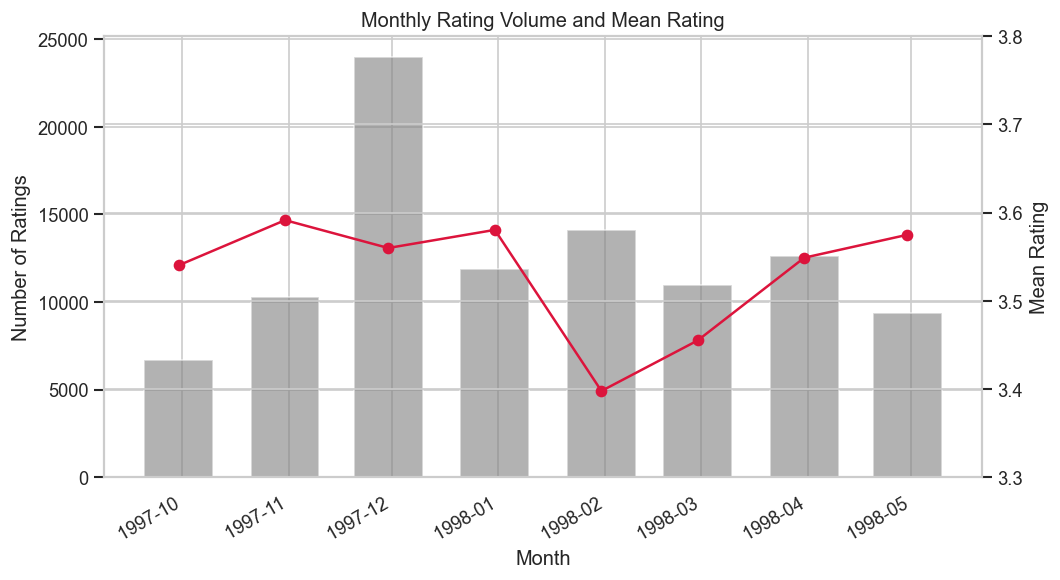

In [21]:
monthly = df.set_index("timestamp").resample("ME")["rating"].agg(["count", "mean"])
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.bar(monthly.index, monthly["count"], width=20, alpha=0.6, color="gray", label="Rating count")
ax2.plot(monthly.index, monthly["mean"], color="crimson", marker="o", label="Mean rating")
ax1.set_title("Monthly Rating Volume and Mean Rating")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Ratings")
ax2.set_ylabel("Mean Rating")
ax2.set_ylim(3.3, 3.8)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIG_DIR / "08_rating_over_time.png")
plt.show()

---
## 9. Multivariate — Gender × Occupation Heatmap (Mean Rating)

**Takeaway:** The heatmap reveals interaction effects: e.g., male engineers and female librarians deviate from their gender-level averages. Main effects of gender or occupation alone miss these cross-segment patterns. A model that includes interaction terms or latent factors is better suited than simple demographic averages.

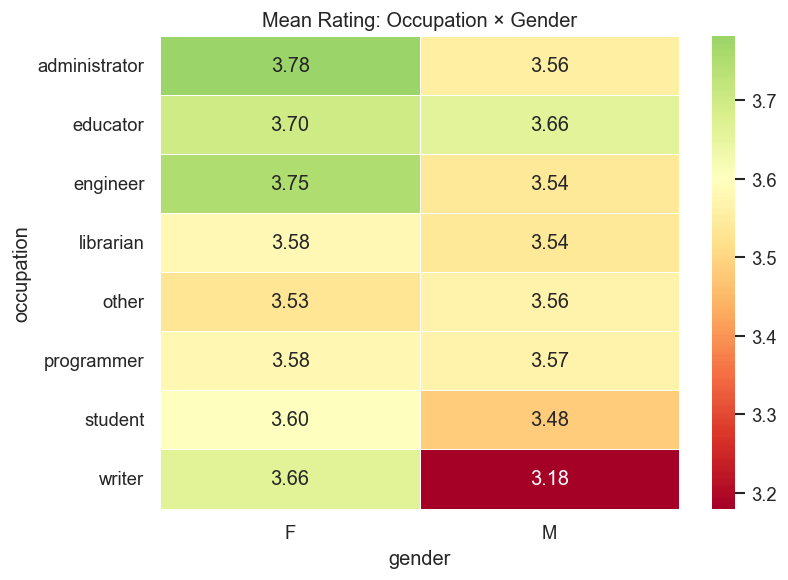

In [22]:
top_occ = df["occupation"].value_counts().head(8).index
subset = df[df["occupation"].isin(top_occ)]
pivot = subset.pivot_table(index="occupation", columns="gender", values="rating", aggfunc="mean")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=3.6, linewidths=0.5, ax=ax)
ax.set_title("Mean Rating: Occupation × Gender")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_gender_occupation_heatmap.png")
plt.show()

---
## 10. Multivariate — Genre × Release Decade (Mean Rating)

**Takeaway:** Drama and Romance maintain consistently high averages across decades, while Horror and Children's show more decade-to-decade variation. Genre and release era interact: a user's preference is jointly shaped by content type and vintage. Item features for modelling should include both genre and release year.

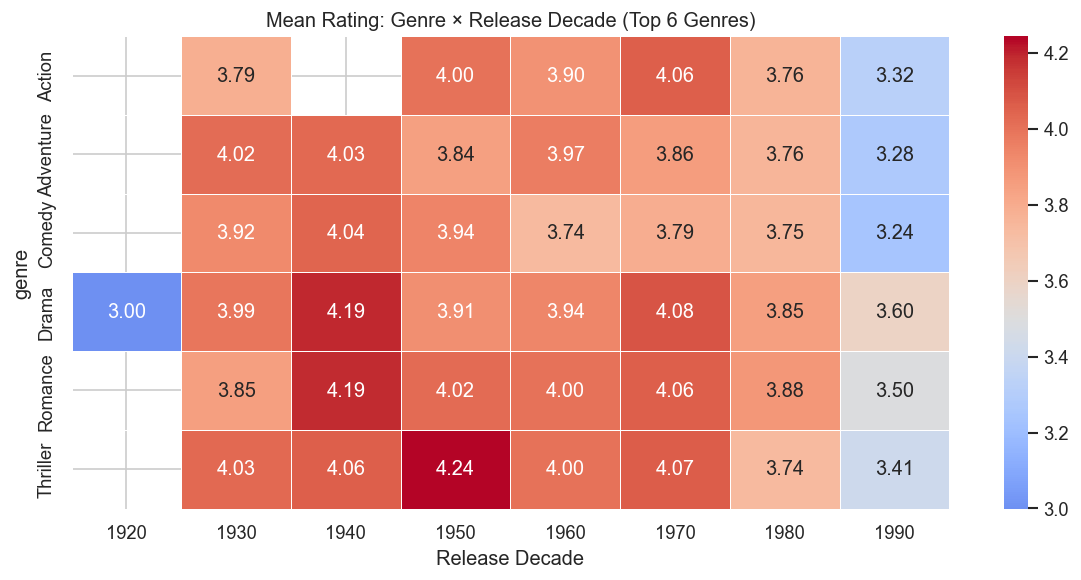

In [23]:
top_genres = df_genre["genre"].value_counts().head(6).index
genre_decade = (
    df_genre[df_genre["genre"].isin(top_genres)]
    .dropna(subset=["release_decade"])
    .groupby(["genre", "release_decade"], observed=True)["rating"]
    .mean()
    .reset_index()
)
pivot_gd = genre_decade.pivot(index="genre", columns="release_decade", values="rating")
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_gd, annot=True, fmt=".2f", cmap="coolwarm", center=3.5, linewidths=0.5, ax=ax)
ax.set_title("Mean Rating: Genre × Release Decade (Top 6 Genres)")
ax.set_xlabel("Release Decade")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_genre_decade_heatmap.png")
plt.show()

---
## Summary Statistics for Report

Key numbers referenced in the written report and revised hypotheses.

In [24]:
global_mean = df["rating"].mean()
print(f"Global mean rating: {global_mean:.3f}")
print("\nGender means:")
print(df.groupby("gender")["rating"].mean().round(3))
print("\nAge group means:")
print(df.groupby("age_group", observed=True)["rating"].mean().round(3))
print("\nTop genres by mean rating (min 500 ratings):")
genre_means = df_genre.groupby("genre")["rating"].agg(["mean", "count"]).query("count >= 500")
print(genre_means.sort_values("mean", ascending=False).head(8).round(3))

Global mean rating: 3.530

Gender means:
gender
F    3.532
M    3.529
Name: rating, dtype: float64

Age group means:
age_group
<18      3.552
18-24    3.471
25-34    3.498
35-44    3.575
45-54    3.622
55+      3.652
Name: rating, dtype: float64

Top genres by mean rating (min 500 ratings):
              mean  count
genre                    
Film-Noir    3.922   1733
War          3.816   9398
Drama        3.687  39895
Documentary  3.673    758
Mystery      3.638   5245
Crime        3.632   8055
Romance      3.622  19461
Western      3.613   1854
